# BIND2 — Physical sanity tests

Beyond pixel- and power-spectrum-level metrics, we want to know whether
BIND2's generated baryon fields satisfy *physical* relationships that the
truth fields do. This notebook runs four such tests and asks how each
depends on the 35 CAMELS parameters:

1. **DM back-reaction** — does the hydro DM profile differ from the
   N-body DMO profile in the same way truth does (halo contraction)?
2. **Stellar–halo mass relation (SHMR)** — does `M_*` scale with `M_h`
   correctly across the suite, and does its normalization respond to
   feedback parameters as truth does?
3. **Baryon fraction profile** — does `f_b(r) = (Gas + Stars) /
   (DM + Gas + Stars)` track truth out to the patch boundary?
4. **Intrinsic alignments** — does the projected stellar major axis
   align with the local DMO major axis as in truth?

**Pipeline.** One pass through the test-suite outputs builds a per-halo
feature table (radial profiles, patch sums, 2D shape moments). Every
downstream section reduces from that table; reruns hit the parquet cache.

## 0. Setup

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '/mnt/home/mlee1/vdm_bind2')
from metrics import CHANNEL_NAMES, radial_profile

plt.rcParams.update({
    'font.size': 10,
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'figure.dpi': 110,
    'savefig.bbox': 'tight',
})

SUITE_ROOT = Path('/mnt/home/mlee1/ceph/fm_testsuite')
SNAP = 'snap_090'
MASS_TAG = 'mass_threshold_1p000e13'
MODEL_NAME = 'fm_two_head'
BOX_SIZE = 50.0
N_PIX_FULL = 1024
PATCH_PIX = 128
PATCH_BOX = BOX_SIZE * PATCH_PIX / N_PIX_FULL   # 6.25 Mpc/h
MPC_PER_PIX = PATCH_BOX / PATCH_PIX
N_PARAMS = 35
N_RBINS = 32

FIG_DIR = Path('paper_figures')
FIG_DIR.mkdir(exist_ok=True)
CACHE_DIR = Path('analysis_physics_cache')
CACHE_DIR.mkdir(exist_ok=True)
CACHE_FILE = CACHE_DIR / f'halo_features_{MODEL_NAME}.npz'

SUITES = ('CV', '1P', 'Test')
SUITE_COLORS = {'CV': 'tab:green', '1P': 'tab:blue', 'Test': 'tab:red'}
SUITE_DISPLAY = {'CV': 'CV', '1P': '1P', 'Test': 'SB35'}

_param_meta = pd.read_csv(
    '/mnt/home/mlee1/Sims/IllustrisTNG_extras/L50n512/SB35/SB35_param_minmax.csv'
)
PARAM_NAMES = {i + 1: n for i, n in enumerate(_param_meta['ParamName'])}
PARAM_LOG = {i + 1: bool(v) for i, v in enumerate(_param_meta['LogFlag'])}
PARAM_LABELS = {
    1:  r'$\Omega_m$',  2:  r'$\sigma_8$',
    3:  r'$A_{\rm SN1}$', 4:  r'$A_{\rm SN2}$',
    5:  r'$A_{\rm AGN1}$', 6:  r'$A_{\rm AGN2}$',
}
for i in range(7, N_PARAMS + 1):
    PARAM_LABELS[i] = PARAM_NAMES.get(i, f'p{i}')

print('Channels :', CHANNEL_NAMES)
print('Patch box:', PATCH_BOX, 'Mpc/h   (1 pix =', f'{MPC_PER_PIX*1000:.1f} kpc/h)')
print('Cache file:', CACHE_FILE)

Channels : ['DM_hydro', 'Gas', 'Stars']
Patch box: 6.25 Mpc/h   (1 pix = 48.8 kpc/h)
Cache file: analysis_physics_cache/halo_features_fm_two_head.npz


## 1. Sim discovery

In [2]:
def sim_record(sim_dir: Path, suite_name: str) -> dict:
    snap = sim_dir / SNAP
    mass = snap / MASS_TAG
    model = mass / MODEL_NAME
    rec = {
        'suite': suite_name,
        'sim_id': sim_dir.name,
        'sim_dir': sim_dir,
        'full_maps':    snap / 'full_maps.npz',
        'halo_catalog': mass / 'halo_catalog.npz',
        'generated':    model / 'generated_halos.npz',
        'composite':    model / 'composite.npz',
        'summary':      model / 'summary.json',
    }
    rec['available'] = all(
        rec[k].exists() for k in ('full_maps', 'halo_catalog', 'generated')
    )
    return rec


def discover_sims(suites=SUITES) -> pd.DataFrame:
    recs = []
    for suite in suites:
        root = SUITE_ROOT / suite
        if not root.exists():
            continue
        for sd in sorted(root.iterdir()):
            if sd.is_dir():
                recs.append(sim_record(sd, suite))
    return pd.DataFrame(recs)


sims_all = discover_sims()
sims = sims_all[sims_all['available']].reset_index(drop=True)
cv_sims   = sims[sims['suite'] == 'CV'].reset_index(drop=True)
oneP_sims = sims[sims['suite'] == '1P'].reset_index(drop=True)
test_sims = sims[sims['suite'] == 'Test'].reset_index(drop=True)
print(f'Available sims: CV={len(cv_sims)}  1P={len(oneP_sims)}  SB35={len(test_sims)}')

Available sims: CV=27  1P=139  SB35=102


## 2. Single-pass per-halo feature ingestion

For each sim we open the three npz files exactly once and produce, per
halo:

- **Radial profiles** (32 bins) of DMO, truth (3 channels), gen (3 channels)
- **Patch-sum mass** for truth and gen, all three channels
- **2D mass-weighted shape moments** `(e1, e2)` for DMO, truth Stars, gen Stars
- **Halo mass** and the 35-element parameter vector

Everything lives in one `numpy` archive on disk. Subsequent sections
load this cache (a few hundred MB max) and never touch raw test-suite
files again. Force a rebuild with `force=True`.

In [3]:
def extract_patch(field_2d, cx, cy, size=PATCH_PIX):
    n = field_2d.shape[0]
    half = size // 2
    ix = (cx - half + np.arange(size)) % n
    iy = (cy - half + np.arange(size)) % n
    return field_2d[np.ix_(ix, iy)]


def centers_to_pixels(centers_mpc):
    ppm = N_PIX_FULL / BOX_SIZE
    return (np.asarray(centers_mpc) * ppm).astype(np.int64) % N_PIX_FULL


_R_PIX = None  # cached radial bin centres in pixels


def stack_radial(maps_3d, n_bins=N_RBINS):
    """Per-sample radial profile, shape (N, n_bins). Caches r-grid."""
    global _R_PIX
    out = np.empty((len(maps_3d), n_bins), dtype=np.float64)
    for i, f in enumerate(maps_3d):
        r_pix, prof = radial_profile(f, n_bins=n_bins)
        out[i] = prof
    _R_PIX = r_pix
    return out


def shape_moments_batch(maps, threshold=0.0, min_pixels=5):
    """Mass-weighted 2D quadrupole → (e1, e2) per map (NaN if invalid)."""
    N, H, W = maps.shape
    yy, xx  = np.mgrid[0:H, 0:W].astype(np.float64)
    e1_out = np.full(N, np.nan); e2_out = np.full(N, np.nan)
    for i in range(N):
        w = np.maximum(maps[i].astype(np.float64) - threshold, 0.0)
        total = w.sum()
        if total < 1e-30 or int((w > 0).sum()) < min_pixels:
            continue
        x_c = (xx * w).sum() / total
        y_c = (yy * w).sum() / total
        dx, dy = xx - x_c, yy - y_c
        Qxx = (dx ** 2 * w).sum() / total
        Qyy = (dy ** 2 * w).sum() / total
        Qxy = (dx * dy * w).sum() / total
        evals, evecs = np.linalg.eigh([[Qxx, Qxy], [Qxy, Qyy]])
        lam_min, lam_max = evals[0], evals[1]
        if lam_max < 1e-30 or lam_min < 0:
            continue
        q   = np.sqrt(lam_min / lam_max)
        pa  = np.arctan2(evecs[1, 1], evecs[0, 1])
        eps = (1 - q) / (1 + q)
        e1_out[i] = eps * np.cos(2 * pa)
        e2_out[i] = eps * np.sin(2 * pa)
    return e1_out, e2_out


def ingest_one(rec):
    """Compute every per-halo feature for one sim."""
    fm  = np.load(rec['full_maps'])
    cat = np.load(rec['halo_catalog'])
    gen = np.load(rec['generated'])['generated']  # (N, 3, 128, 128)
    centers_pix = centers_to_pixels(cat['centers'])
    n = len(centers_pix)
    dmo   = np.zeros((n, PATCH_PIX, PATCH_PIX), dtype=np.float32)
    truth = np.zeros((n, 3, PATCH_PIX, PATCH_PIX), dtype=np.float32)
    for i, (cx, cy) in enumerate(centers_pix):
        dmo[i] = extract_patch(fm['dmo_fullbox'], cx, cy)
        for c in range(3):
            truth[i, c] = extract_patch(fm['truth_maps'][c], cx, cy)

    p_dmo = stack_radial(dmo)                                   # (n, 32)
    p_t   = np.stack([stack_radial(truth[:, c]) for c in range(3)], axis=1)  # (n, 3, 32)
    p_g   = np.stack([stack_radial(gen[:, c])   for c in range(3)], axis=1)
    m_t   = truth.sum(axis=(2, 3))                              # (n, 3)
    m_g   = gen.sum(axis=(2, 3))                                # (n, 3)

    e1_d,  e2_d  = shape_moments_batch(dmo)
    e1_st, e2_st = shape_moments_batch(truth[:, 2])
    e1_sg, e2_sg = shape_moments_batch(gen[:, 2])

    masses = np.asarray(cat['masses'], dtype=np.float64)
    params = (np.asarray(cat['params'], dtype=np.float32)
              if 'params' in cat.files else np.full((n, N_PARAMS), np.nan, np.float32))

    return dict(
        suite=np.array([rec['suite']] * n),
        sim_id=np.array([rec['sim_id']] * n),
        logM=np.log10(masses),
        params=params,
        p_dmo=p_dmo,
        p_t=p_t, p_g=p_g,
        m_t=m_t, m_g=m_g,
        e1_d=e1_d, e2_d=e2_d,
        e1_st=e1_st, e2_st=e2_st,
        e1_sg=e1_sg, e2_sg=e2_sg,
    )


def build_cache(sims_df, force=False):
    if CACHE_FILE.exists() and not force:
        print(f'Loading cache from {CACHE_FILE}')
        z = np.load(CACHE_FILE, allow_pickle=False)
        return {k: z[k] for k in z.files}, z['r_pix'] * MPC_PER_PIX

    print(f'Building cache for {len(sims_df)} sims...')
    parts = []
    for k, rec in enumerate(sims_df.to_dict('records')):
        try:
            parts.append(ingest_one(rec))
        except Exception as exc:
            print(f'[skip] {rec["suite"]}/{rec["sim_id"]}: {exc}')
            continue
        if (k + 1) % 25 == 0:
            print(f'  {k+1}/{len(sims_df)} sims done')

    keys = parts[0].keys()
    merged = {k: np.concatenate([p[k] for p in parts], axis=0) for k in keys}
    merged['r_pix'] = _R_PIX

    np.savez_compressed(CACHE_FILE, **merged)
    print(f'Wrote {CACHE_FILE}  ({CACHE_FILE.stat().st_size / 1e6:.1f} MB)')
    print(f'  total halos: {len(merged["logM"])}')
    return merged, merged['r_pix'] * MPC_PER_PIX


halos, r_mpc = build_cache(sims, force=False)
print('Halo count by suite:')
for s in SUITES:
    n = (halos['suite'] == s).sum()
    print(f'  {SUITE_DISPLAY[s]:>5s}: {n}')

Loading cache from analysis_physics_cache/halo_features_fm_two_head.npz
Halo count by suite:
     CV: 1567
     1P: 9375
   SB35: 5643


### Slim halo dataframe

For convenience we also build a tabular view of the *scalar* per-halo
fields (suite, sim_id, logM, params, patch masses, ellipticities). The
heavy radial-profile arrays stay in `halos`, indexed in the same order.

In [4]:
def build_halos_df(h):
    n = len(h['logM'])
    df = pd.DataFrame({
        'suite':  h['suite'],
        'sim_id': h['sim_id'],
        'logM':   h['logM'],
        'logMs_t': np.log10(np.where(h['m_t'][:, 2] > 0, h['m_t'][:, 2], np.nan)),
        'logMs_g': np.log10(np.where(h['m_g'][:, 2] > 0, h['m_g'][:, 2], np.nan)),
        'e1_d':  h['e1_d'],   'e2_d':  h['e2_d'],
        'e1_st': h['e1_st'],  'e2_st': h['e2_st'],
        'e1_sg': h['e1_sg'],  'e2_sg': h['e2_sg'],
    })
    for j in range(N_PARAMS):
        df[f'p{j+1}'] = h['params'][:, j]
    return df


halos_df = build_halos_df(halos)
print(halos_df.head(3))

  suite sim_id       logM    logMs_t    logMs_g      e1_d      e2_d     e1_st  \
0    CV  sim_0  14.524484  12.585643  12.662561 -0.036850  0.042739 -0.093159   
1    CV  sim_0  14.143168  12.329145  12.379683 -0.052701  0.068678 -0.159041   
2    CV  sim_0  14.132497  12.276159  12.306301  0.020604  0.116551 -0.001647   

      e2_st     e1_sg  ...  p26    p27  p28  p29  p30  p31  p32     p33   p34  \
0  0.155769 -0.060524  ...  0.2  0.002  2.0  1.0  0.0  1.0  0.0  0.0013  1.12   
1  0.209521 -0.188920  ...  0.2  0.002  2.0  1.0  0.0  1.0  0.0  0.0013  1.12   
2 -0.009789  0.000944  ...  0.2  0.002  2.0  1.0  0.0  1.0  0.0  0.0013  1.12   

   p35  
0  2.0  
1  2.0  
2  2.0  

[3 rows x 46 columns]


## 3. Plot helpers

Two plotters that every downstream section reuses:

- `plot_radial_stack` — for any per-halo profile array `(N, n_r)`, stack
  by halo-mass bin and plot truth vs BIND2 with shaded percentile bands.
- `param_response_grid` — given a per-sim scalar table, plot a 5×7 grid
  showing how truth and BIND2 respond to each of the 35 parameters.

In [5]:
MASS_EDGES = np.array([13.0, 13.3, 13.7, 15.5])
SUITE_ORDER  = ['Test', '1P', 'CV']
SUITE_MARKER = {'Test': '.', '1P': 's', 'CV': 'o'}
SUITE_MS     = {'Test': 2,  '1P': 4,  'CV': 4}
SUITE_ALPHA  = {'Test': 0.35, '1P': 0.9, 'CV': 0.9}


def _band(arr):
    return (np.nanmedian(arr, 0),
            np.nanquantile(arr, 0.16, 0),
            np.nanquantile(arr, 0.84, 0))


def plot_radial_stack(suite_to_curves, r_mpc, ylim, ylabel, title,
                      ref_line=None, save_name=None):
    """`suite_to_curves[suite]` = list of (label, truth_arr, gen_arr) per mass-bin row."""
    suites = list(suite_to_curves.keys())
    bins_per_row = max(len(rows) for rows in suite_to_curves.values())
    fig, axes = plt.subplots(len(suites), bins_per_row,
                             figsize=(4.0 * bins_per_row, 3.3 * len(suites)),
                             sharex=True, sharey=True, squeeze=False)
    for row, suite in enumerate(suites):
        for col in range(bins_per_row):
            ax = axes[row, col]
            entries = suite_to_curves[suite]
            if col >= len(entries):
                ax.axis('off'); continue
            label, t_arr, g_arr = entries[col]
            m_t, lo_t, hi_t = _band(t_arr)
            m_g, lo_g, hi_g = _band(g_arr)
            ax.fill_between(r_mpc, lo_t, hi_t, color='k', alpha=0.18)
            ax.plot(r_mpc, m_t, color='k', lw=1.4, label='Truth')
            ax.fill_between(r_mpc, lo_g, hi_g, color='tab:orange', alpha=0.25)
            ax.plot(r_mpc, m_g, color='tab:orange', lw=1.4, label='BIND2')
            if ref_line is not None:
                ax.axhline(ref_line[0], color='gray', lw=0.6, ls=ref_line[1])
            ax.set_xscale('log'); ax.set_xlim(0.02, PATCH_BOX / 2)
            if ylim is not None:
                ax.set_ylim(*ylim)
            if row == 0:
                ax.set_title(label, fontsize=10)
            if col == 0:
                ax.set_ylabel(rf'{SUITE_DISPLAY[suite]}   {ylabel}', fontsize=10)
            if row == len(suites) - 1:
                ax.set_xlabel(r'$r$ [Mpc/h]')
            if row == 0 and col == 0:
                ax.legend(loc='best', fontsize=8)
            ax.grid(alpha=0.3)
    fig.suptitle(title, y=0.995, fontsize=12)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    if save_name:
        for ext in ('pdf', 'png'):
            fig.savefig(FIG_DIR / f'{save_name}.{ext}')
    return fig


def param_response_grid(tbl, ylim, ylabel, title, ref=None, save_name=None):
    n_rows, n_cols = 5, 7
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 11), sharey=True)
    for j in range(N_PARAMS):
        r, c = divmod(j, n_cols)
        ax = axes[r, c]
        pname  = f'p{j + 1}'
        label  = PARAM_LABELS.get(j + 1, pname)
        for s in SUITE_ORDER:
            sub = tbl[tbl['suite'] == s]
            if s == '1P':
                pj_prefix = f'1P_p{j + 1}_'
                mask = sub['sim_id'].str.startswith(pj_prefix) | (sub['sim_id'] == '1P_p1_0')
                sub = sub[mask]
            if len(sub) == 0:
                continue
            x = sub[pname].to_numpy()
            ax.scatter(x, sub['truth'].to_numpy(),
                       marker=SUITE_MARKER[s], s=12 + 2 * SUITE_MS[s],
                       facecolors='none', edgecolors='k',
                       alpha=SUITE_ALPHA[s], lw=0.6,
                       label=f'{SUITE_DISPLAY[s]} truth' if j == 0 else None)
            ax.scatter(x, sub['gen'].to_numpy(),
                       marker=SUITE_MARKER[s], s=12 + 2 * SUITE_MS[s],
                       color=SUITE_COLORS[s], alpha=SUITE_ALPHA[s],
                       label=f'{SUITE_DISPLAY[s]} BIND2' if j == 0 else None)
        if ref is not None:
            ax.axhline(ref, color='gray', lw=0.5, ls='--', alpha=0.6)
        if PARAM_LOG.get(j + 1, False):
            ax.set_xscale('log')
        ax.set_xlabel(label, fontsize=9)
        ax.set_ylim(*ylim)
        ax.grid(alpha=0.2)
        if c == 0:
            ax.set_ylabel(ylabel, fontsize=9)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='lower right', ncol=min(len(handles), 6),
                   fontsize=10, bbox_to_anchor=(0.99, 0.0), frameon=True)
    fig.suptitle(title, y=0.995, fontsize=15)
    fig.tight_layout(rect=(0, 0.02, 1, 0.98))
    if save_name:
        for ext in ('pdf', 'png'):
            fig.savefig(FIG_DIR / f'{save_name}.{ext}')
    return fig


def per_sim_scalar(halos_df, value_t, value_g, sim_filter=None):
    """Aggregate per-halo (truth_arr, gen_arr) into one row per sim."""
    if len(value_t) != len(halos_df):
        raise ValueError('value arrays must align with halos_df rows')
    df = halos_df.copy()
    df['_truth'] = value_t
    df['_gen']   = value_g
    if sim_filter is not None:
        df = df[sim_filter(df)]
    grp = df.groupby('sim_id', as_index=False)
    out = grp.agg(
        suite=('suite', 'first'),
        truth=('_truth', 'median'),
        gen=('_gen', 'median'),
        **{f'p{j+1}': (f'p{j+1}', 'first') for j in range(N_PARAMS)},
    )
    out = out.dropna(subset=['truth', 'gen']).reset_index(drop=True)
    return out

## 4. DM back-reaction

Per-halo back-reaction ratio `R_DM(r) = Σ_DM_hydro(r) / Σ_DMO(r)`. `R > 1`
indicates baryonic contraction; `R < 1` indicates expansion. The per-sim
scalar is the median ratio over the inner half of the patch.

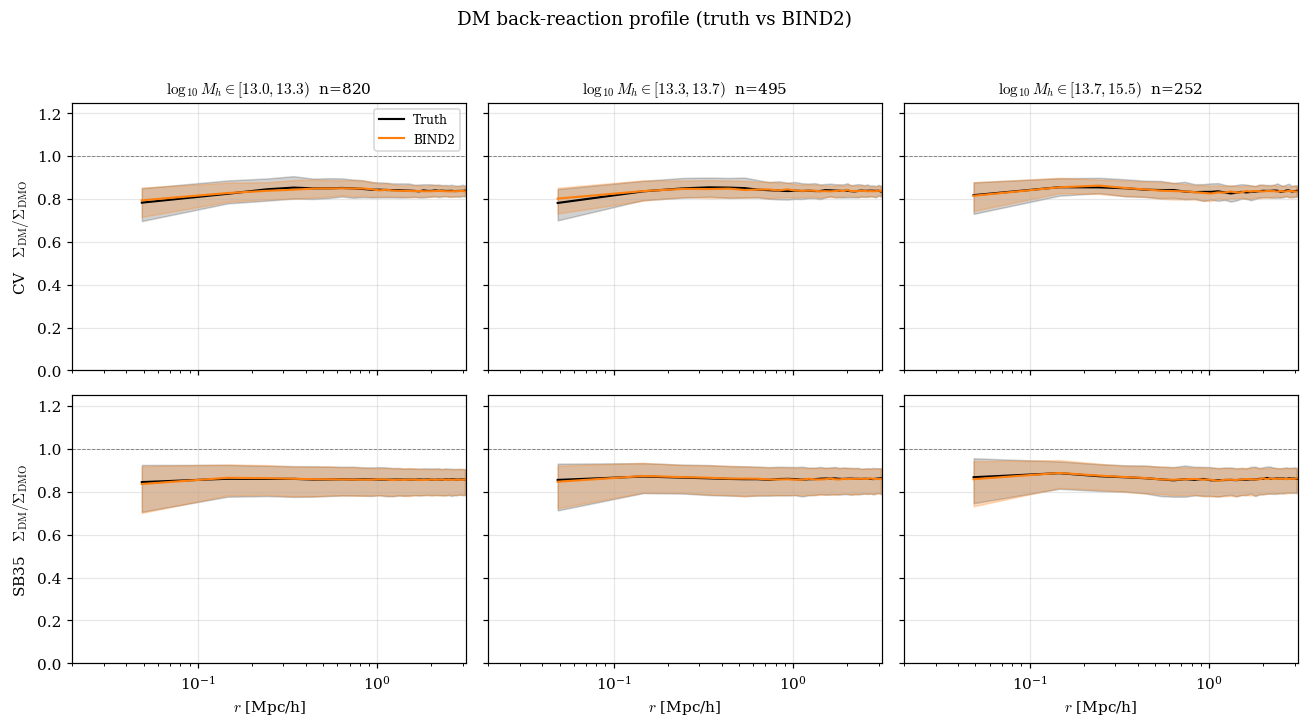

In [6]:
with np.errstate(divide='ignore', invalid='ignore'):
    R_t = np.where(halos['p_dmo'] > 0, halos['p_t'][:, 0] / halos['p_dmo'], np.nan)
    R_g = np.where(halos['p_dmo'] > 0, halos['p_g'][:, 0] / halos['p_dmo'], np.nan)


def by_mass_bin(arr, suite, edges=MASS_EDGES):
    out = []
    for bi in range(len(edges) - 1):
        sel = (halos['suite'] == suite) & (halos['logM'] >= edges[bi]) & (halos['logM'] < edges[bi + 1])
        if sel.sum() == 0:
            continue
        out.append((
            f'$\\log_{{10}} M_h \\in [{edges[bi]:.1f},{edges[bi+1]:.1f})$  n={int(sel.sum())}',
            arr[sel],
        ))
    return out


def stacks_for(arr_t, arr_g, suites=('CV', 'Test')):
    return {
        s: [(label, t, arr_g[(halos['suite'] == s) & np.isin(np.arange(len(arr_t)),
              np.where((halos['suite'] == s) & (halos['logM'] >= MASS_EDGES[bi]) & (halos['logM'] < MASS_EDGES[bi+1]))[0])])
            for bi, (label, t) in enumerate(by_mass_bin(arr_t, s))]
        for s in suites
    }


# More direct construction
def stacks_for_clean(arr_t, arr_g, suites=('CV', 'Test')):
    out = {}
    for s in suites:
        rows = []
        for bi in range(len(MASS_EDGES) - 1):
            sel = ((halos['suite'] == s)
                   & (halos['logM'] >= MASS_EDGES[bi])
                   & (halos['logM'] < MASS_EDGES[bi + 1]))
            if sel.sum() == 0:
                continue
            label = (f'$\\log_{{10}} M_h \\in [{MASS_EDGES[bi]:.1f},'
                     f'{MASS_EDGES[bi+1]:.1f})$  n={int(sel.sum())}')
            rows.append((label, arr_t[sel], arr_g[sel]))
        out[s] = rows
    return out


plot_radial_stack(
    stacks_for_clean(R_t, R_g),
    r_mpc,
    ylim=(0., 1.25),
    ylabel=r'$\Sigma_{\rm DM}/\Sigma_{\rm DMO}$',
    title='DM back-reaction profile (truth vs BIND2)',
    ref_line=(1.0, '--'),
    save_name='physics_dm_backreaction_profile',
)
plt.show()

suite
1P      139
CV       27
Test    102
dtype: int64


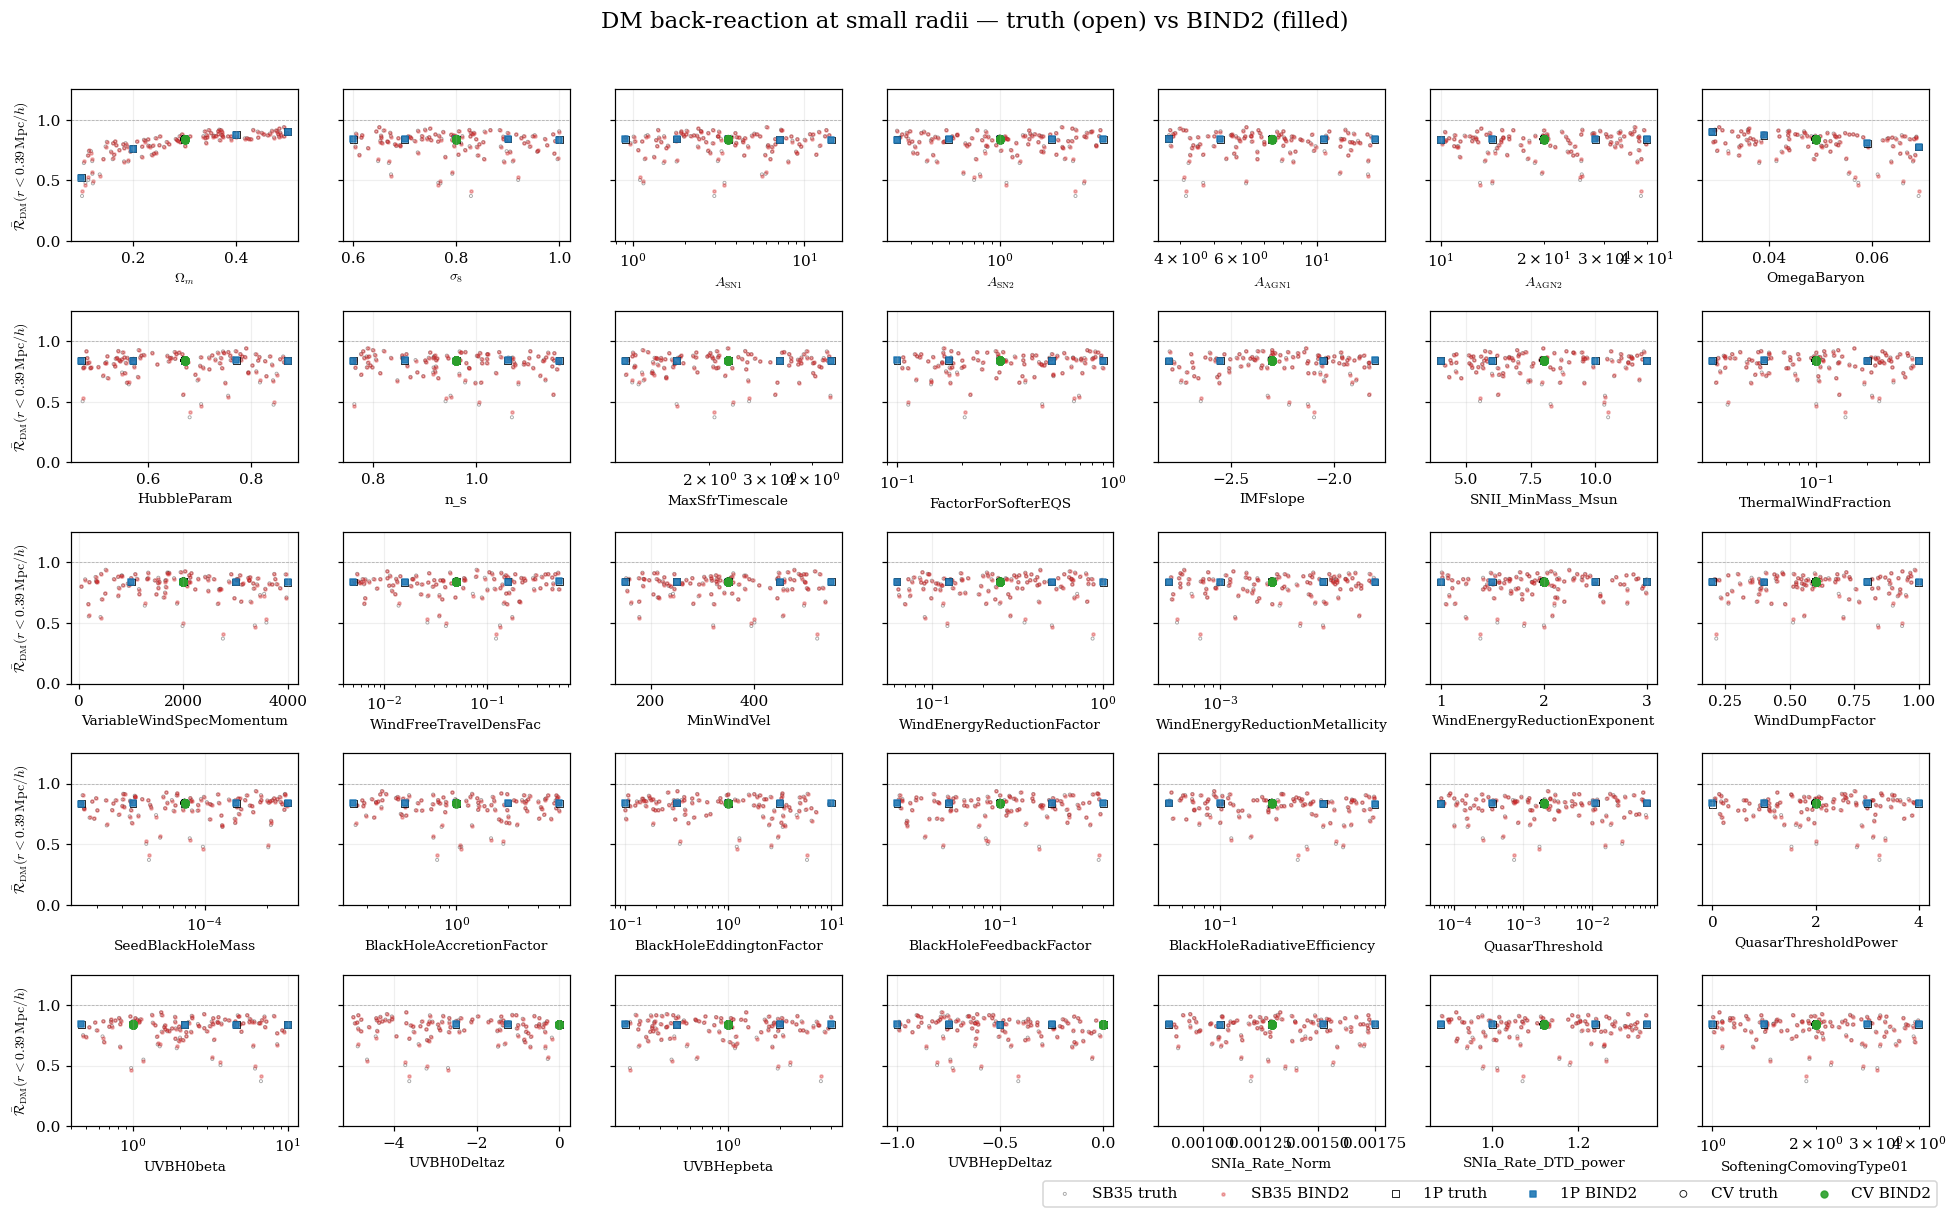

In [7]:
# Per-sim scalar: median back-reaction over inner half of patch.
inner_mask = r_mpc < (PATCH_BOX / 4)
v_t = np.nanmedian(R_t[:, inner_mask], axis=1)
v_g = np.nanmedian(R_g[:, inner_mask], axis=1)
dm_tbl = per_sim_scalar(halos_df, v_t, v_g)
print(dm_tbl.groupby('suite').size())

param_response_grid(
    dm_tbl,
    ylim=(0.0, 1.25),
    ylabel=r'$\bar{\mathcal{R}}_{\rm DM}(r<0.39\,{\rm Mpc}/h)$',
    title='DM back-reaction at small radii — truth (open) vs BIND2 (filled)',
    ref=1.0,
    save_name='physics_dm_backreaction',
)
plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def corr_response_matrix(tbl, stat_cols, suite_sel=None, method='spearman'):
    if suite_sel is not None:
        tbl = tbl[tbl['suite'].isin(suite_sel)].copy()

    params = [f'p{j+1}' for j in range(N_PARAMS)]
    truth_mat = np.full((len(stat_cols), len(params)), np.nan)
    gen_mat   = np.full((len(stat_cols), len(params)), np.nan)

    for i, scol in enumerate(stat_cols):
        y_t = tbl[f'{scol}_truth'].to_numpy()
        y_g = tbl[f'{scol}_gen'].to_numpy()

        for j, pcol in enumerate(params):
            x = tbl[pcol].to_numpy()
            m_t = np.isfinite(x) & np.isfinite(y_t)
            m_g = np.isfinite(x) & np.isfinite(y_g)

            if method == 'spearman':
                if np.sum(m_t) > 3:
                    truth_mat[i, j] = spearmanr(x[m_t], y_t[m_t]).statistic
                if np.sum(m_g) > 3:
                    gen_mat[i, j] = spearmanr(x[m_g], y_g[m_g]).statistic
            else:
                if np.sum(m_t) > 3:
                    truth_mat[i, j] = np.corrcoef(x[m_t], y_t[m_t])[0, 1]
                if np.sum(m_g) > 3:
                    gen_mat[i, j] = np.corrcoef(x[m_g], y_g[m_g])[0, 1]

    return params, truth_mat, gen_mat

def plot_corr_heatmaps(tbl, stat_cols, stat_labels=None, suite_sel=None,
                       method='spearman', save_name=None):
    params, C_t, C_g = corr_response_matrix(
        tbl, stat_cols, suite_sel=suite_sel, method=method
    )
    C_d = C_g - C_t

    if stat_labels is None:
        stat_labels = stat_cols

    fig, axes = plt.subplots(1, 3, figsize=(1.8*len(params) + 8, 0.55*len(stat_cols) + 4),
                             constrained_layout=True)

    v = 1.0 if method == 'spearman' else np.nanmax(np.abs([C_t, C_g]))
    im0 = axes[0].imshow(C_t, vmin=-v, vmax=v, cmap='coolwarm', aspect='auto')
    im1 = axes[1].imshow(C_g, vmin=-v, vmax=v, cmap='coolwarm', aspect='auto')
    im2 = axes[2].imshow(C_d, vmin=-0.5, vmax=0.5, cmap='PiYG', aspect='auto')

    titles = ['Truth', 'BIND2', 'BIND2 - Truth']
    for ax, title in zip(axes, titles):
        ax.set_title(title)
        ax.set_xticks(np.arange(len(params)))
        ax.set_xticklabels([PARAM_LABELS.get(i+1, p) for i, p in enumerate(params)],
                           rotation=45, ha='right')
        ax.set_yticks(np.arange(len(stat_labels)))
        ax.set_yticklabels(stat_labels)

    cbar0 = fig.colorbar(im0, ax=axes[:2], shrink=0.9, pad=0.02)
    cbar0.set_label(f'{method.capitalize()} correlation')
    cbar1 = fig.colorbar(im2, ax=axes[2], shrink=0.9, pad=0.02)
    cbar1.set_label(r'$\Delta \rho$')

    if save_name:
        for ext in ('png', 'pdf'):
            fig.savefig(FIG_DIR / f'{save_name}.{ext}', dpi=200, bbox_inches='tight')
    return fig

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def per_sim_scalar_from_arrays(sim_id, suite, param_matrix, value_t, value_g, mask=None):
    n = len(sim_id)
    sim_id = np.asarray(sim_id)
    suite = np.asarray(suite)
    value_t = np.asarray(value_t)
    value_g = np.asarray(value_g)
    param_matrix = np.asarray(param_matrix)

    if mask is None:
        mask = np.ones(n, dtype=bool)

    if value_t.shape[0] != n or value_g.shape[0] != n or suite.shape[0] != n or param_matrix.shape[0] != n:
        raise ValueError("All inputs must have the same first dimension.")

    data = {
        'sim_id': sim_id[mask],
        'suite': suite[mask],
        'truth': value_t[mask],
        'gen': value_g[mask],
    }
    for j in range(param_matrix.shape[1]):
        data[f'p{j+1}'] = param_matrix[mask, j]

    df = pd.DataFrame(data)

    grp = df.groupby('sim_id', as_index=False)
    out = grp.agg(
        suite=('suite', 'first'),
        truth=('truth', 'median'),
        gen=('gen', 'median'),
        **{f'p{j+1}': (f'p{j+1}', 'first') for j in range(param_matrix.shape[1])},
    )
    out = out.dropna(subset=['truth', 'gen']).reset_index(drop=True)
    return out


def plot_massbin_corr_heatmaps_arrays(
    sim_id, suite, logM, param_matrix, value_t, value_g,
    mass_edges, param_labels=None, suite_sel=('CV', 'Test'),
    method='spearman', save_name=None
):
    sim_id = np.asarray(sim_id)
    suite = np.asarray(suite)
    logM = np.asarray(logM)
    param_matrix = np.asarray(param_matrix)
    value_t = np.asarray(value_t)
    value_g = np.asarray(value_g)

    n_params = param_matrix.shape[1]
    if param_labels is None:
        param_labels = [f'p{j+1}' for j in range(n_params)]

    row_labels = []
    C_t, C_g = [], []

    for bi in range(len(mass_edges) - 1):
        lo, hi = mass_edges[bi], mass_edges[bi + 1]
        mask = np.isin(suite, suite_sel) & (logM >= lo) & (logM < hi)

        if mask.sum() == 0:
            continue

        tbl = per_sim_scalar_from_arrays(
            sim_id, suite, param_matrix, value_t, value_g, mask=mask
        )

        if len(tbl) < 4:
            continue

        row_t, row_g = [], []
        for j in range(n_params):
            p = f'p{j+1}'
            x = tbl[p].to_numpy()
            yt = tbl['truth'].to_numpy()
            yg = tbl['gen'].to_numpy()

            mt = np.isfinite(x) & np.isfinite(yt)
            mg = np.isfinite(x) & np.isfinite(yg)

            if method == 'spearman':
                ct = spearmanr(x[mt], yt[mt], nan_policy='omit').statistic if mt.sum() >= 4 else np.nan
                cg = spearmanr(x[mg], yg[mg], nan_policy='omit').statistic if mg.sum() >= 4 else np.nan
            else:
                ct = np.corrcoef(x[mt], yt[mt])[0, 1] if mt.sum() >= 4 else np.nan
                cg = np.corrcoef(x[mg], yg[mg])[0, 1] if mg.sum() >= 4 else np.nan

            row_t.append(ct)
            row_g.append(cg)

        C_t.append(row_t)
        C_g.append(row_g)
        row_labels.append(rf'$\log_{{10}} M_h \in [{lo:.1f},{hi:.1f})$')

    C_t = np.array(C_t)
    C_g = np.array(C_g)
    C_d = C_g - C_t

    fig, axes = plt.subplots(1, 3, figsize=(16, 3.2 + 0.9*len(row_labels)),
                             constrained_layout=True)

    im0 = axes[0].imshow(C_t, vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
    im1 = axes[1].imshow(C_g, vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
    im2 = axes[2].imshow(C_d, vmin=-0.5, vmax=0.5, cmap='PiYG', aspect='auto')

    for ax, title in zip(axes, ['Truth', 'BIND2', 'BIND2 - Truth']):
        ax.set_title(title)
        ax.set_xticks(np.arange(n_params))
        ax.set_xticklabels(param_labels, rotation=45, ha='right')
        ax.set_yticks(np.arange(len(row_labels)))
        ax.set_yticklabels(row_labels)
        ax.tick_params(length=0)

    cb0 = fig.colorbar(im0, ax=axes[:2], shrink=0.9, pad=0.02)
    cb0.set_label(f'{method.capitalize()} correlation')
    cb1 = fig.colorbar(im2, ax=axes[2], shrink=0.9, pad=0.02)
    cb1.set_label(r'$\Delta \rho$')

    if save_name:
        for ext in ('png', 'pdf'):
            fig.savefig(FIG_DIR / f'{save_name}.{ext}', dpi=200, bbox_inches='tight')

    return fig

In [10]:
with np.errstate(divide='ignore', invalid='ignore'):
    R_t = np.where(halos['p_dmo'] > 0, halos['p_t'][:, 0] / halos['p_dmo'], np.nan)
    R_g = np.where(halos['p_dmo'] > 0, halos['p_g'][:, 0] / halos['p_dmo'], np.nan)

param_matrix = halos['params']   # replace with your actual key

param_labels = [PARAM_LABELS.get(j + 1, f'p{j+1}') for j in range(param_matrix.shape[1])]

plot_massbin_corr_heatmaps_arrays(
    sim_id=halos['sim_id'],
    suite=halos['suite'],
    logM=halos['logM'],
    param_matrix=param_matrix,
    value_t=R_t,
    value_g=R_g,
    mass_edges=MASS_EDGES,
    param_labels=param_labels,
    suite_sel=('CV', 'Test'),
    method='spearman',
    save_name='physics_dm_backreaction_corr_response',
)
plt.show()

ValueError: Per-column arrays must each be 1-dimensional

## 5. Stellar–halo mass relation (SHMR)

`M_*^patch` is the 2D-projected pixel sum (consistent across truth and
BIND2; not directly comparable to spectroscopic SHMR). Per-sim scalar:
median `log10 M_*` in the central halo-mass bin `[13.4, 13.6)`.

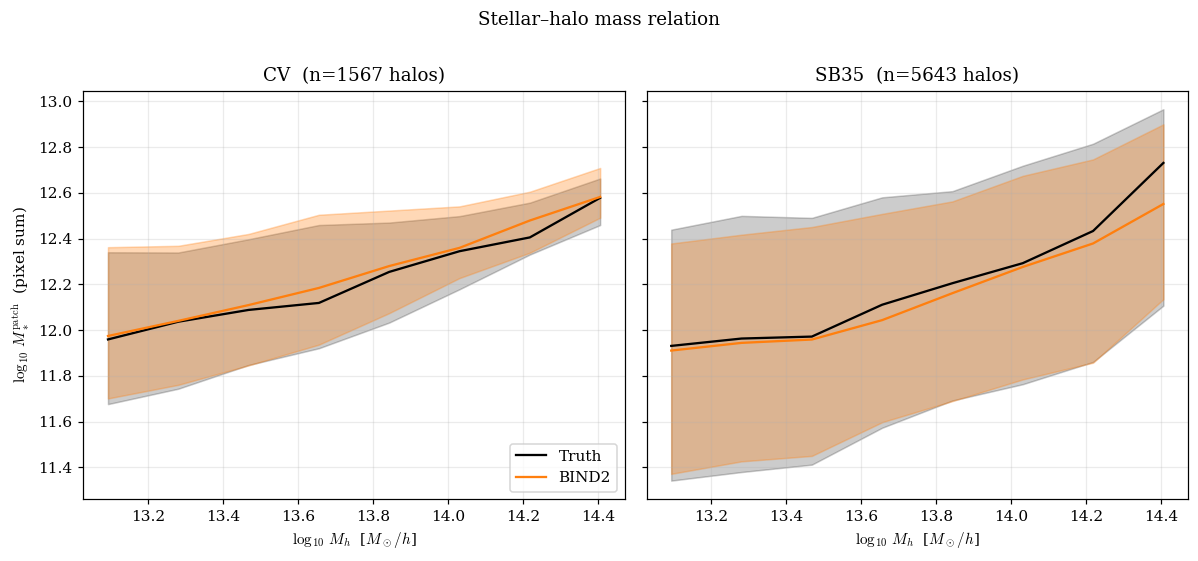

In [11]:
SHMR_BINS = np.linspace(13.0, 14.5, 9)
SHMR_CENTRES = 0.5 * (SHMR_BINS[:-1] + SHMR_BINS[1:])


def shmr_curve(suite):
    sel_suite = halos['suite'] == suite
    med_t = np.full(len(SHMR_CENTRES), np.nan)
    lo_t  = np.full_like(med_t, np.nan); hi_t = np.full_like(med_t, np.nan)
    med_g = np.full_like(med_t, np.nan); lo_g = np.full_like(med_t, np.nan); hi_g = np.full_like(med_t, np.nan)
    logM   = halos['logM']
    logMs_t = halos_df['logMs_t'].to_numpy()
    logMs_g = halos_df['logMs_g'].to_numpy()
    for b in range(len(SHMR_CENTRES)):
        sel = sel_suite & (logM >= SHMR_BINS[b]) & (logM < SHMR_BINS[b + 1])
        if sel.sum() < 5:
            continue
        v_t = logMs_t[sel]; v_t = v_t[np.isfinite(v_t)]
        v_g = logMs_g[sel]; v_g = v_g[np.isfinite(v_g)]
        if len(v_t) >= 5:
            med_t[b] = np.median(v_t); lo_t[b] = np.quantile(v_t, 0.16); hi_t[b] = np.quantile(v_t, 0.84)
        if len(v_g) >= 5:
            med_g[b] = np.median(v_g); lo_g[b] = np.quantile(v_g, 0.16); hi_g[b] = np.quantile(v_g, 0.84)
    return med_t, lo_t, hi_t, med_g, lo_g, hi_g


fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for ax, suite_name, title in zip(axes, ['CV', 'Test'], ['CV', 'SB35']):
    m_t, lo_t, hi_t, m_g, lo_g, hi_g = shmr_curve(suite_name)
    ax.fill_between(SHMR_CENTRES, lo_t, hi_t, color='k', alpha=0.2)
    ax.plot(SHMR_CENTRES, m_t, 'k-', lw=1.5, label='Truth')
    ax.fill_between(SHMR_CENTRES, lo_g, hi_g, color='tab:orange', alpha=0.3)
    ax.plot(SHMR_CENTRES, m_g, color='tab:orange', lw=1.5, label='BIND2')
    n = int((halos['suite'] == suite_name).sum())
    ax.set_xlabel(r'$\log_{10}\,M_h$  [$M_\odot/h$]')
    ax.set_title(f'{title}  (n={n} halos)')
    ax.grid(alpha=0.25)
    if ax is axes[0]:
        ax.set_ylabel(r'$\log_{10}\,M_*^{\rm patch}$  (pixel sum)')
        ax.legend(loc='lower right')
fig.suptitle('Stellar–halo mass relation', y=1.01, fontsize=12)
fig.tight_layout()
plt.show()

suite
1P      139
CV       27
Test    101
dtype: int64


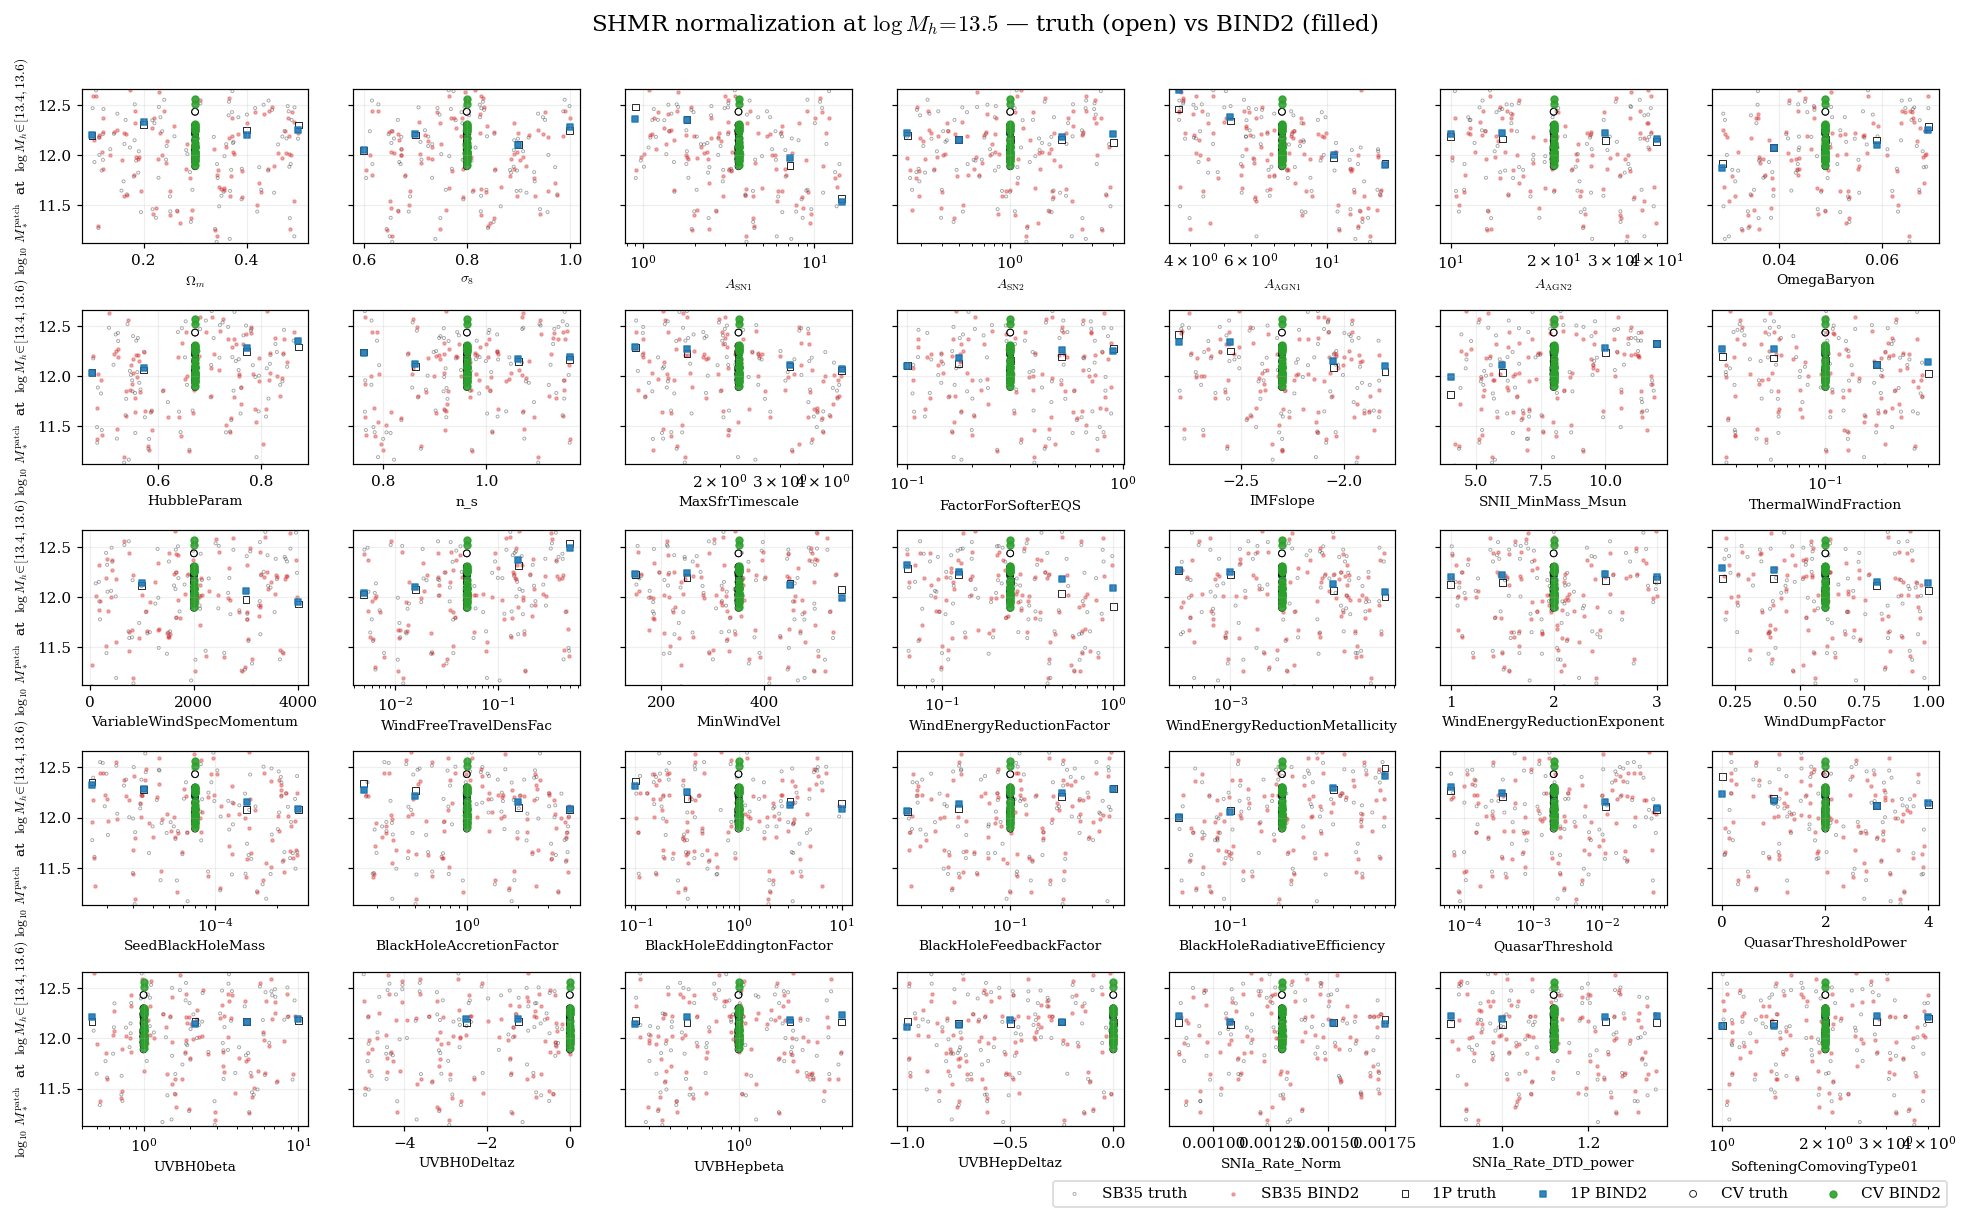

In [12]:
SHMR_REF_LO, SHMR_REF_HI = 13.4, 13.6
ref_mask = (halos['logM'] >= SHMR_REF_LO) & (halos['logM'] < SHMR_REF_HI)


def _agg_shmr(df):
    return pd.Series({
        'suite': df['suite'].iloc[0],
        'truth': df.loc[ref_mask[df.index], 'logMs_t'].median(),
        'gen':   df.loc[ref_mask[df.index], 'logMs_g'].median(),
        **{f'p{j+1}': df[f'p{j+1}'].iloc[0] for j in range(N_PARAMS)},
    })


shmr_tbl = (halos_df[ref_mask]
            .groupby('sim_id', as_index=False)
            .agg(suite=('suite', 'first'),
                 truth=('logMs_t', 'median'),
                 gen=('logMs_g', 'median'),
                 **{f'p{j+1}': (f'p{j+1}', 'first') for j in range(N_PARAMS)}))
shmr_tbl = shmr_tbl.dropna(subset=['truth', 'gen']).reset_index(drop=True)
print(shmr_tbl.groupby('suite').size())

truth_vals = shmr_tbl['truth'].to_numpy()
ylo = np.nanquantile(truth_vals, 0.02) - 0.05
yhi = np.nanquantile(truth_vals, 0.98) + 0.05
param_response_grid(
    shmr_tbl,
    ylim=(ylo, yhi),
    ylabel=r'$\log_{10}\,M_*^{\rm patch}$  at  $\log M_h\!\in\![13.4,13.6)$',
    title='SHMR normalization at $\\log M_h\\!=\\!13.5$ — truth (open) vs BIND2 (filled)',
    save_name='physics_shmr_norm',
)
plt.show()

## 6. Baryon fraction profile

`f_b(r) = (Gas + Stars) / (DM + Gas + Stars)`. The dotted reference line
is the cosmic baryon fraction `Ω_b/Ω_m = 0.049/0.3 ≈ 0.163`. Per-sim
scalar: median `f_b` over the outer half of the patch.

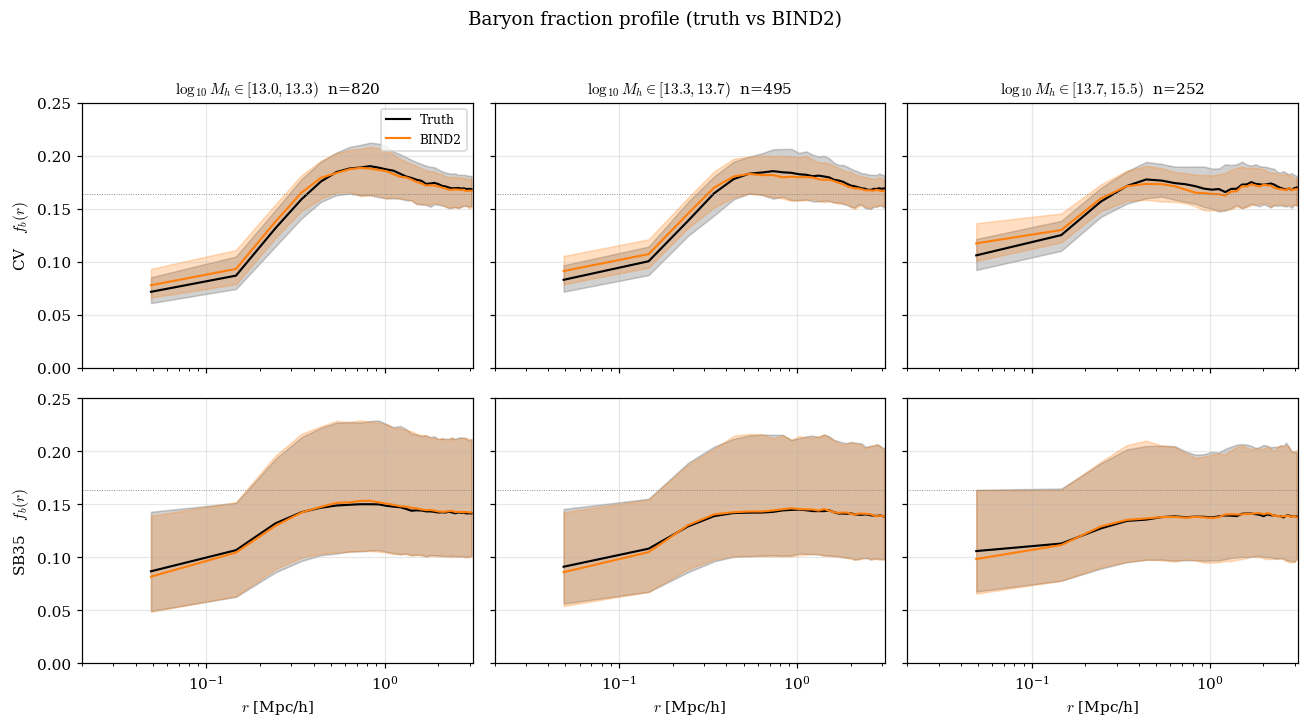

In [13]:
with np.errstate(divide='ignore', invalid='ignore'):
    fb_t = (halos['p_t'][:, 1] + halos['p_t'][:, 2]) / (
        halos['p_t'][:, 0] + halos['p_t'][:, 1] + halos['p_t'][:, 2])
    fb_g = (halos['p_g'][:, 1] + halos['p_g'][:, 2]) / (
        halos['p_g'][:, 0] + halos['p_g'][:, 1] + halos['p_g'][:, 2])


plot_radial_stack(
    stacks_for_clean(fb_t, fb_g),
    r_mpc,
    ylim=(0.0, 0.25),
    ylabel=r'$f_b(r)$',
    title='Baryon fraction profile (truth vs BIND2)',
    ref_line=(0.049 / 0.3, ':'),
    save_name='physics_baryon_fraction_profile',
)
plt.show()

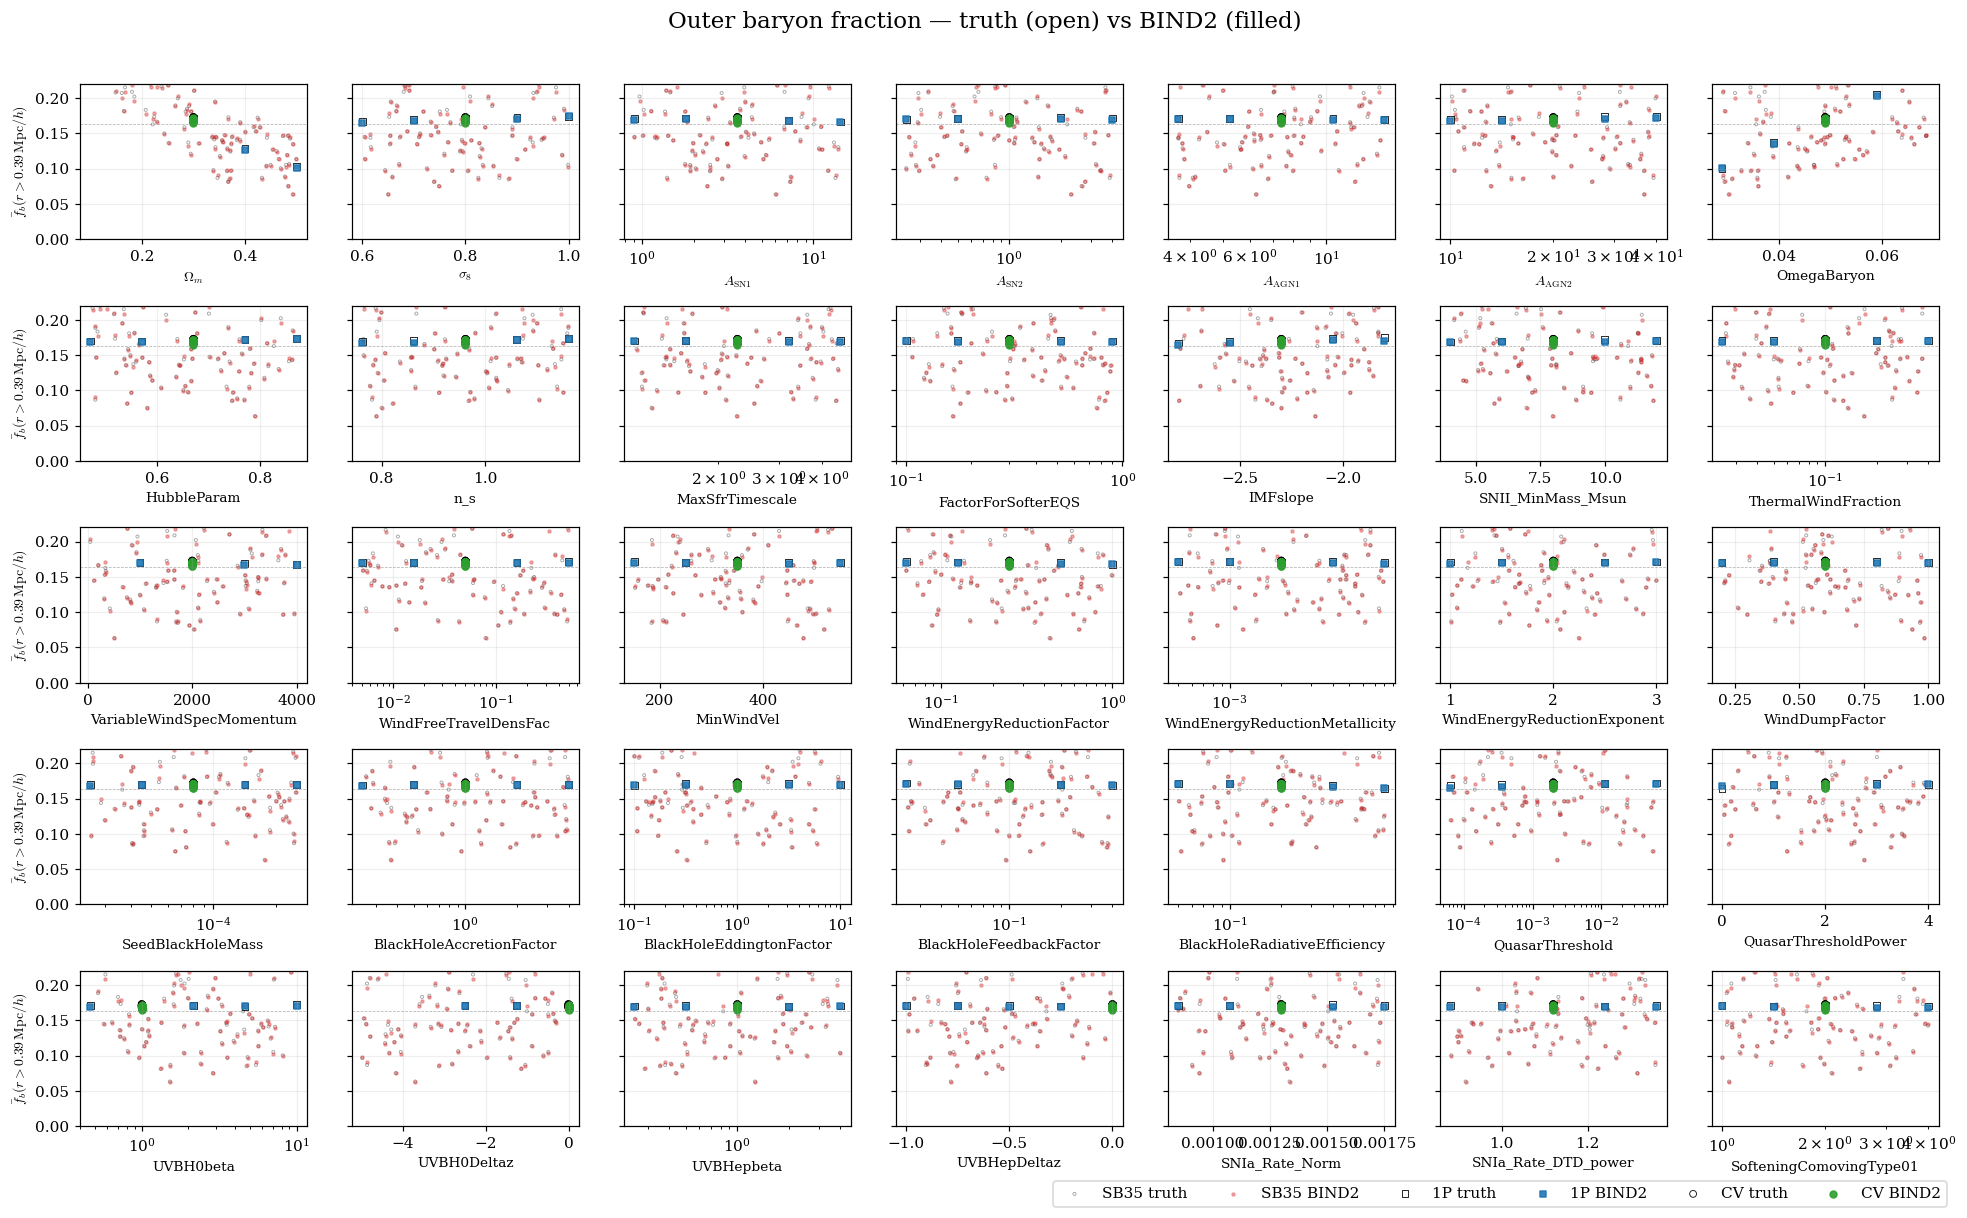

In [14]:
outer_mask = r_mpc > (PATCH_BOX / 4)
v_t = np.nanmedian(fb_t[:, outer_mask], axis=1)
v_g = np.nanmedian(fb_g[:, outer_mask], axis=1)
fb_tbl = per_sim_scalar(halos_df, v_t, v_g)

param_response_grid(
    fb_tbl,
    ylim=(0.0, 0.22),
    ylabel=r'$\bar{f}_b(r>0.39\,{\rm Mpc}/h)$',
    title='Outer baryon fraction — truth (open) vs BIND2 (filled)',
    ref=0.049 / 0.3,
    save_name='physics_baryon_fraction',
)
plt.show()

## 7. Intrinsic alignments

Mass-weighted 2D quadrupole moments (cached in `halos_df`) define
ellipticities for the stellar field and the DMO field. The IA estimator

$$e_+ \;=\; \frac{e_1^\star\,e_1^{\rm DMO} + e_2^\star\,e_2^{\rm DMO}}{|\varepsilon_{\rm DMO}|}$$

projects the stellar shape onto the DMO major axis. We require
`|ε_DMO| > 0.05` for a well-defined projection (matches the convention
in `paper_figures.ipynb`).

Valid IA halos: 14046 / 16585


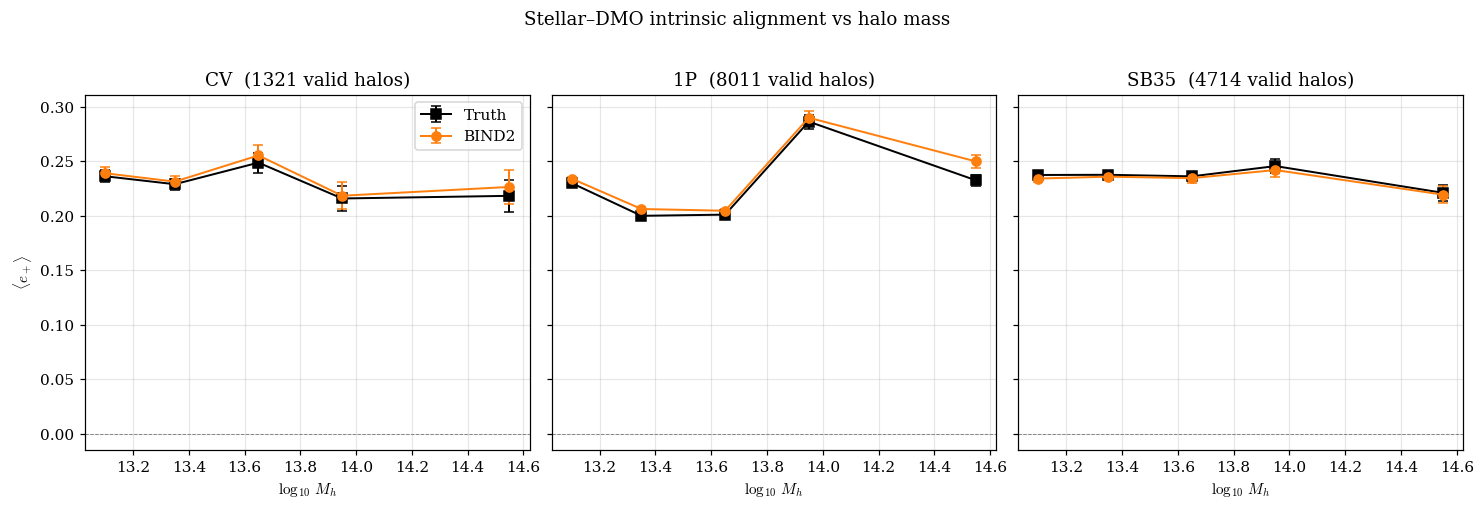

In [12]:
IA_EPS_MIN = 0.05
IA_MASS_EDGES = np.array([13.0, 13.2, 13.5, 13.8, 14.1, 15.0])
IA_CENTRES    = 0.5 * (IA_MASS_EDGES[:-1] + IA_MASS_EDGES[1:])

eps_d = np.hypot(halos_df['e1_d'], halos_df['e2_d']).to_numpy()
with np.errstate(invalid='ignore', divide='ignore'):
    e_plus_t = (halos_df['e1_st'] * halos_df['e1_d']
                + halos_df['e2_st'] * halos_df['e2_d']).to_numpy() / eps_d
    e_plus_g = (halos_df['e1_sg'] * halos_df['e1_d']
                + halos_df['e2_sg'] * halos_df['e2_d']).to_numpy() / eps_d
ia_valid = (eps_d > IA_EPS_MIN) & np.isfinite(e_plus_t) & np.isfinite(e_plus_g)
print('Valid IA halos:', ia_valid.sum(), '/', len(ia_valid))


def ia_binned(suite):
    sel_s = (halos['suite'] == suite) & ia_valid
    means_t, sems_t = [], []
    means_g, sems_g = [], []
    ns = []
    for b in range(len(IA_MASS_EDGES) - 1):
        sel = sel_s & (halos['logM'] >= IA_MASS_EDGES[b]) & (halos['logM'] < IA_MASS_EDGES[b + 1])
        n = int(sel.sum()); ns.append(n)
        if n >= 5:
            v_t = e_plus_t[sel]; v_g = e_plus_g[sel]
            means_t.append(v_t.mean()); sems_t.append(v_t.std() / np.sqrt(n))
            means_g.append(v_g.mean()); sems_g.append(v_g.std() / np.sqrt(n))
        else:
            means_t.append(np.nan); means_g.append(np.nan)
            sems_t.append(np.nan);  sems_g.append(np.nan)
    return (np.array(means_t), np.array(sems_t),
            np.array(means_g), np.array(sems_g), np.array(ns))


fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.5), sharey=True)
for ax, suite in zip(axes, ['CV', '1P', 'Test']):
    m_t, s_t, m_g, s_g, ns = ia_binned(suite)
    ax.errorbar(IA_CENTRES, m_t, yerr=s_t, fmt='ks-', lw=1.3, capsize=3, label='Truth')
    ax.errorbar(IA_CENTRES, m_g, yerr=s_g, fmt='o-', lw=1.3, capsize=3,
                color='tab:orange', label='BIND2')
    ax.axhline(0.0, color='gray', lw=0.6, ls='--')
    n_total = int(((halos['suite'] == suite) & ia_valid).sum())
    ax.set_xlabel(r'$\log_{10}\,M_h$')
    ax.set_title(f'{SUITE_DISPLAY[suite]}  ({n_total} valid halos)')
    ax.grid(alpha=0.3)
    if ax is axes[0]:
        ax.set_ylabel(r'$\langle e_+\rangle$')
        ax.legend()
fig.suptitle('Stellar–DMO intrinsic alignment vs halo mass', y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

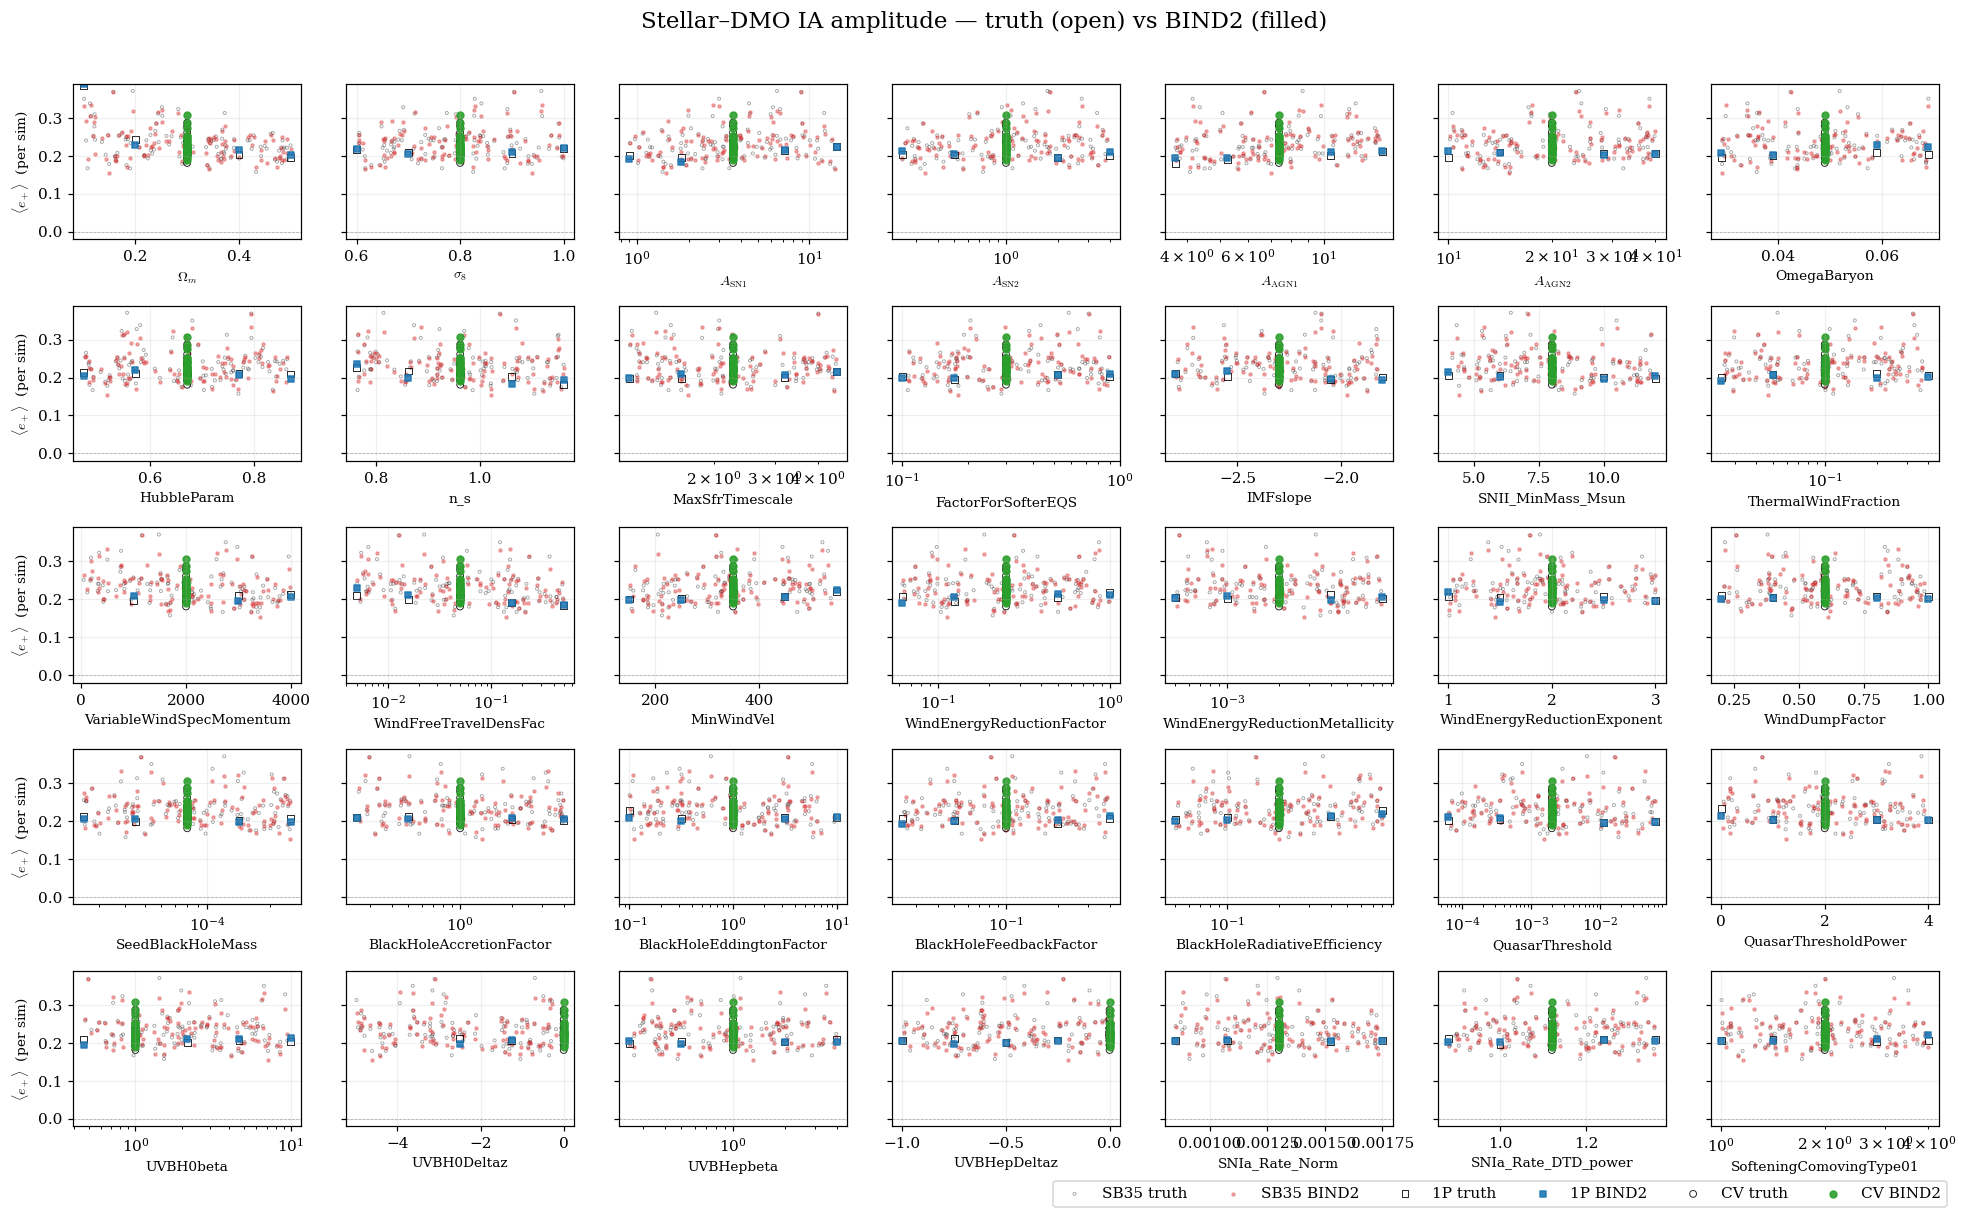

In [13]:
v_t = np.where(ia_valid, e_plus_t, np.nan)
v_g = np.where(ia_valid, e_plus_g, np.nan)
ia_tbl = per_sim_scalar(halos_df, v_t, v_g)

truth_vals = ia_tbl['truth'].to_numpy()
ylim = (-0.02, max(0.05, np.nanquantile(truth_vals, 0.99) + 0.02))
param_response_grid(
    ia_tbl,
    ylim=ylim,
    ylabel=r'$\langle e_+\rangle$  (per sim)',
    title='Stellar–DMO IA amplitude — truth (open) vs BIND2 (filled)',
    ref=0.0,
    save_name='physics_intrinsic_alignment',
)
plt.show()

## 8. Summary

Files written to `paper_figures/`:
- `physics_dm_backreaction_profile.{pdf,png}` (Section 4)
- `physics_dm_backreaction.{pdf,png}` (Section 4)
- `physics_shmr_norm.{pdf,png}` (Section 5)
- `physics_baryon_fraction_profile.{pdf,png}` (Section 6)
- `physics_baryon_fraction.{pdf,png}` (Section 6)
- `physics_intrinsic_alignment.{pdf,png}` (Section 7)

Cache: `analysis_physics_cache/halo_features_<MODEL_NAME>.npz`. Delete
or pass `force=True` to `build_cache` to regenerate after a new model
run.

For each metric the open markers are the per-sim *truth* value and the
filled markers are *BIND2*. Where the two tracks agree across the param
range, BIND2 has captured the physical response; where they diverge, the
parameter axis names which physics is unresolved.